### Supplementary Fig. 13A: no. of hybrid and short-read MAGs with/without CRISPR arrays
CRISPR arrays were identified in hybrid and short-read MAGs using CRISPRCasFinder, and evidence level 3 and 4 CRISPR arrays were retained.

In [1]:
import pandas as pd

df_hym = pd.read_csv('../data/SPMP_MAG-info.tsv', sep='\t', usecols=['mag_id','has_crispr'])
df_hym['assembly type'] = 'long-read'

df_srm = pd.read_csv('../data/hybrid_vs_shortread_comparison/shortread_MAG-info.tsv', sep='\t', usecols=['mag_id','has_crispr'])
df_srm['assembly type'] = 'short-read'

df = pd.concat([df_hym,df_srm], ignore_index=True)

In [2]:
counts = df.groupby(['assembly type', 'has_crispr']).size().unstack(fill_value=0)
counts = counts[[1, 0]]

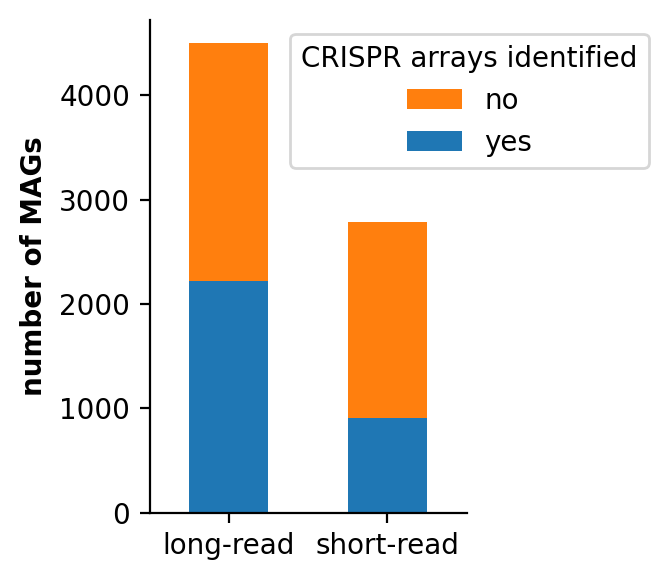

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(3, 3), dpi=200)

counts.plot(kind='bar', stacked=True, ax=ax)

ax.set_xticklabels(['long-read','short-read'], rotation=0)
ax.set_xlabel('')
ax.set_ylabel('number of MAGs', fontweight='bold')

ax.legend()
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], ['no','yes'],title='CRISPR arrays identified', loc='upper left', bbox_to_anchor=(0.4,1))

plt.tight_layout()
sns.despine()

### Supplementary Fig. 13B: length of non-viral regions of short-read vs. hybrid viral contigs
*All* identified viral sequences by VirSorter2+CheckV and geNomad, including duplicates, are input. Duplicates are combined when compiling overlapping regions.

In [4]:
import pandas as pd
import numpy as np

df_hy = pd.read_csv('../data/all_viral-info.tsv', sep='\t')
df_sr = pd.read_csv('../data/hybrid_vs_shortread_comparison/shortread_all_viral-info.tsv', sep='\t')

In [5]:
# sort the start and end positions of each region and sort regions by start position
def get_alignments(df, col1, col2):
    arr = np.sort(df[[col1, col2]].to_numpy(), axis=1)
    return arr[arr[:, 0].argsort()]

# compile (overlapping) regions to obtain total region length
def get_alignment_length(alns):
    if len(alns) == 0:
        return 0
    sum_aln_len = 0
    current_start, current_end = alns[0]
    for i in range(1,len(alns)):
        if alns[i][0] <= current_end: # still part of the same contiguous block
            if alns[i][1] > current_end: # extend contiguous block
                current_end = alns[i][1]
        else: # different contiguous block
            sum_aln_len += current_end - current_start + 1
            current_start, current_end = alns[i]
    sum_aln_len += current_end - current_start + 1 # sum last contiguous block
    return sum_aln_len

In [6]:
df_hy1 = df_hy.groupby(['sample_id','contig_id'], as_index=False).apply(lambda x: pd.Series({
    'contig_len': x.contig_len.values[0],
    'viral_len': get_alignment_length(get_alignments(x,'start_bp','end_bp')),
    'mag_id': x.mag_id.values[0]
}))

df_sr1 = df_sr.groupby(['sample_id','contig_id'], as_index=False).apply(lambda x: pd.Series({
    'contig_len': x.contig_len.values[0],
    'viral_len': get_alignment_length(get_alignments(x,'start_bp','end_bp')),
    'mag_id': x.mag_id.values[0]
}))

C:\Users\chenhr\AppData\Local\Temp\ipykernel_30172\3198871263.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_hy1 = df_hy.groupby(['sample_id','contig_id'], as_index=False).apply(lambda x: pd.Series({
C:\Users\chenhr\AppData\Local\Temp\ipykernel_30172\3198871263.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sr1 = df_sr.groupby(['sample_id','contig_id'], as_index=False).apply(lambda x: pd.Series({


In [7]:
df_hy1['nonviral_len'] = df_hy1.contig_len - df_hy1.viral_len
df_sr1['nonviral_len'] = df_sr1.contig_len - df_sr1.viral_len

df_hy1['assembly type'] = 'long-read'
df_sr1['assembly type'] = 'short-read'

df = pd.concat([df_hy1, df_sr1], ignore_index=True)

Only viral contigs with flanking nonviral regions and binned in MAGs were plotted. These are contigs that were linked to a host MAG. Manual inspection revealed that viral contigs with litte to no flanking host region are sometimes likely misbinned (e.g. a vOTU belonging to a Firmicutes VFC but binned with a Bacteroidota MAG). All such instances were found to be excluded when thresholding to at least 10kbp flanking nonviral region.

In [8]:
df_inmag = df.loc[~df.mag_id.isnull() & (df.nonviral_len > 0)]

"**>10× increase** in prophage sequence context assembled"

In [9]:
df_inmag[df_inmag['assembly type'] == 'long-read']['nonviral_len'].median()/df_inmag[df_inmag['assembly type'] == 'short-read']['nonviral_len'].median()

np.float64(10.946533429483878)

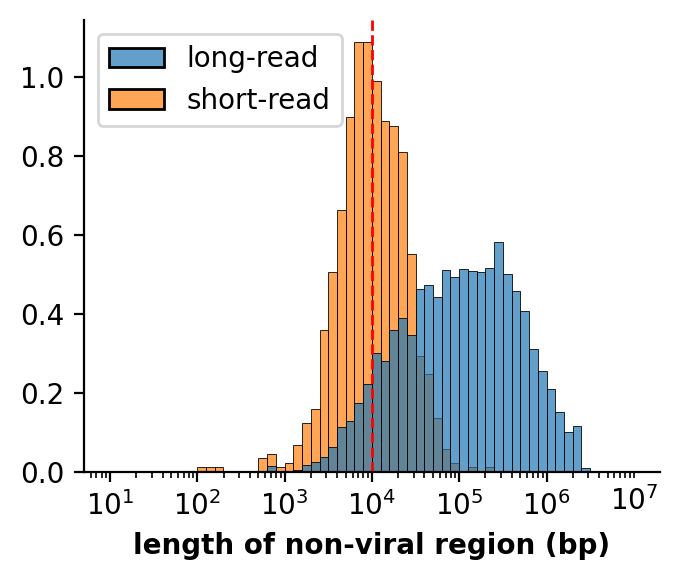

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import ticker

fig, ax = plt.subplots(figsize=(3.5, 3), dpi=200)

bins = [np.log10(b) for b in np.logspace(1, 7, 6*10 + 1)]

sns.histplot(data=df_inmag, x='nonviral_len', hue='assembly type', log_scale=True, bins=bins, stat='density', ax=ax, alpha=0.7, common_norm=False)

ax.set_ylabel('')
ax.set_xlabel('length of non-viral region (bp)', fontweight='bold')

minorLocator = ticker.LogLocator(base=10, subs=np.arange(0.1,1,0.1), numticks=10)
ax.xaxis.set_minor_locator(minorLocator)
plt.xticks([1e1,1e2,1e3,1e4,1e5,1e6])

sns.move_legend(ax, title=None, loc='upper left')

ax.axvline(1e4, color='r', linestyle='--', linewidth=1)

sns.despine()
plt.tight_layout()